In [4]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 2.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 2.6/8.1 MB 2.5 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.4 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.1 MB 2.4 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.1 MB 2.3 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install seaborn
!pip install wordcloud
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
#Load Dataset and Clean Data

In [16]:
df = pd.read_csv("Global_AI_Content_Impact_Dataset.csv")

In [17]:
df.columns = data.columns.str.strip()

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
#Handle missing values if any

In [20]:
df.dropna(inplace=True)

In [21]:
#3. BASIC EXPLORATION

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [23]:
df.describe(include='all')

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200,200.000000,200,200.000000,200.00000,200.000000,200.000000,200.000000,200,200,200.000000,200.000000
unique,10,NaN,10,NaN,NaN,NaN,NaN,NaN,7,3,NaN,NaN
top,India,NaN,Media,NaN,NaN,NaN,NaN,NaN,Midjourney,Moderate,NaN,NaN
freq,24,NaN,31,NaN,NaN,NaN,NaN,NaN,37,76,NaN,NaN
mean,NaN,2022.315000,NaN,54.265850,46.07260,25.788250,39.719450,54.102150,NaN,NaN,59.425150,26.569550
std,NaN,1.825496,NaN,24.218067,29.16122,13.901105,23.829545,19.247079,NaN,NaN,17.319668,14.023729
min,NaN,2020.000000,NaN,10.530000,1.04000,0.090000,0.140000,20.210000,NaN,NaN,30.120000,1.180000
25%,NaN,2021.000000,NaN,33.222500,20.32250,14.995000,17.907500,37.770000,NaN,NaN,44.755000,14.052500
50%,NaN,2022.000000,NaN,53.310000,44.32000,25.735000,42.100000,54.515000,NaN,NaN,59.215000,27.390000
75%,NaN,2024.000000,NaN,76.220000,71.62000,37.417500,58.697500,69.402500,NaN,NaN,74.885000,38.432500


In [24]:
df['Country'].nunique()

10

In [25]:
df['Industry'].nunique()

10

In [26]:
df['Year'].unique()

array([2022, 2025, 2021, 2023, 2020, 2024])

In [27]:
#4. CORRELATION MATRIX

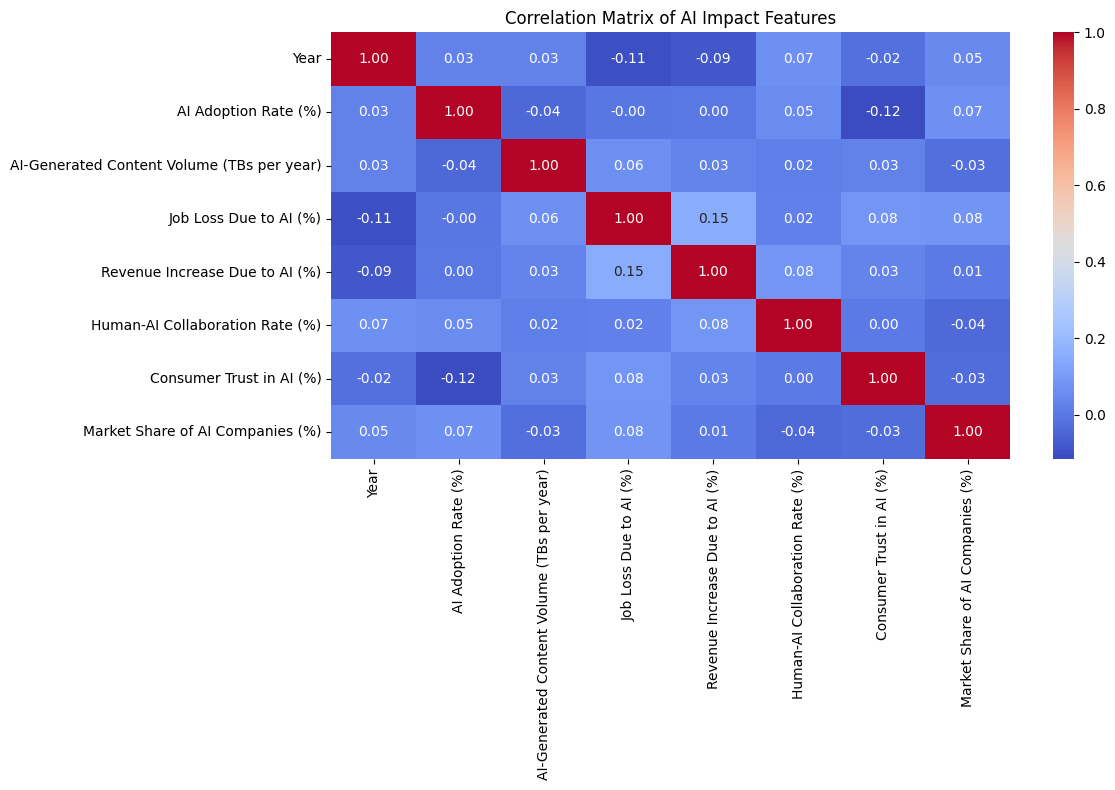

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of AI Impact Features")
plt.tight_layout()
plt.show()

In [29]:
#5. AI ADOPTION RATE MAP (CHOROPLETH)

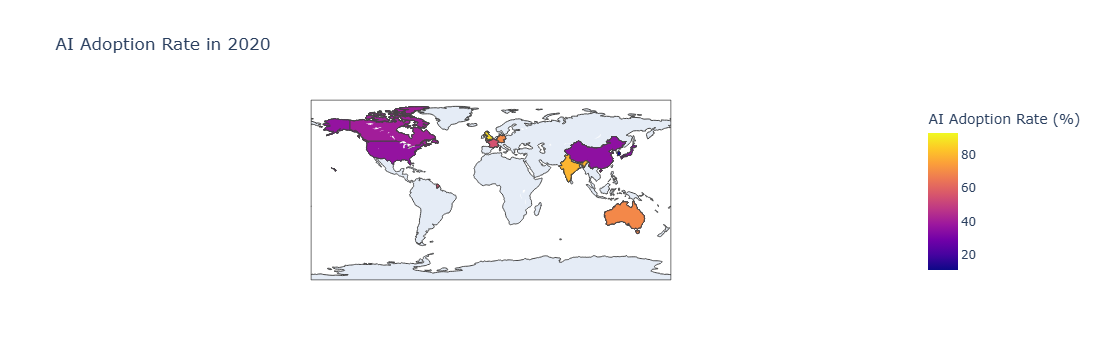

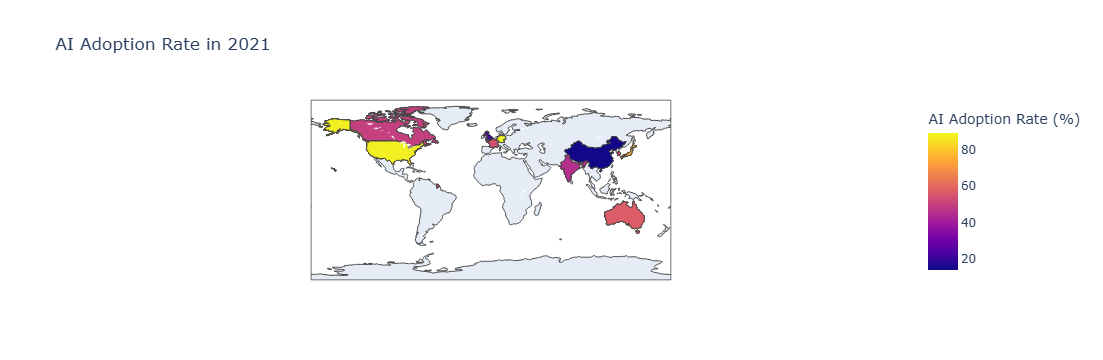

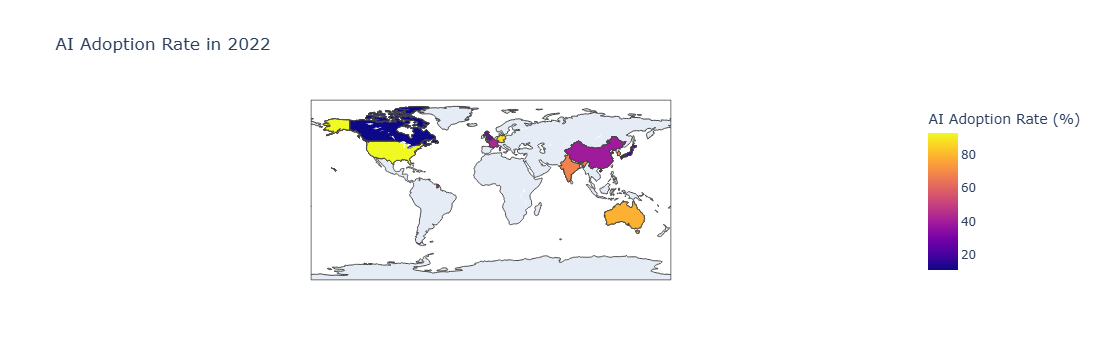

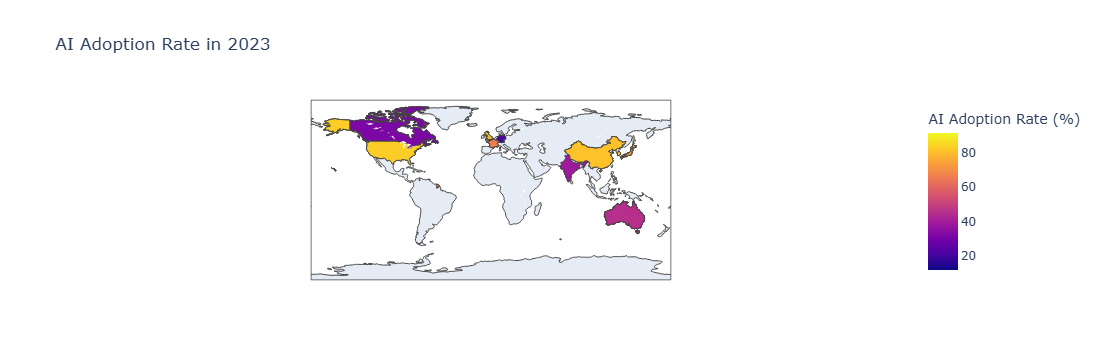

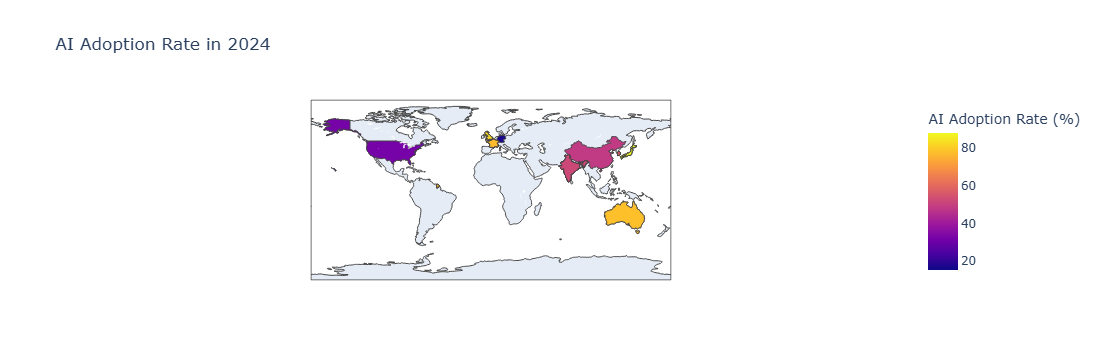

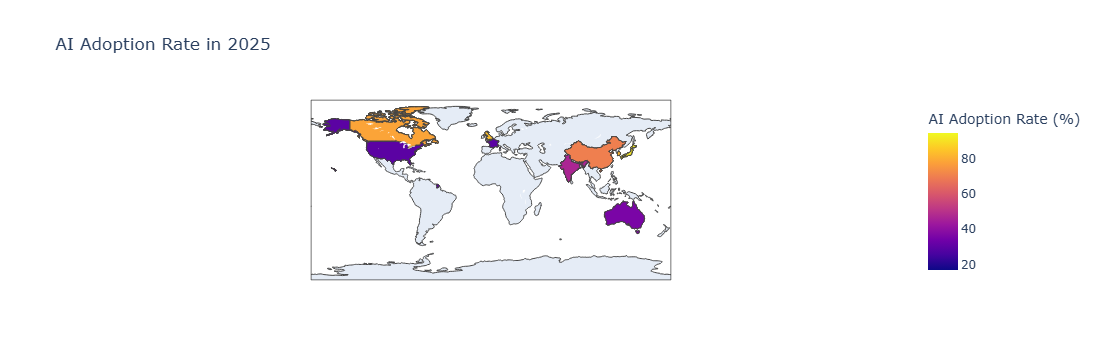

In [30]:
years = sorted(df['Year'].unique())
for year in years:
    data_year = df[df['Year'] == year]
    fig = px.choropleth(data_year, locations="Country", locationmode="country names",
                        color="AI Adoption Rate (%)", hover_name="Country",
                        title=f"AI Adoption Rate in {year}")
    fig.show()

In [31]:
#6. AI JOB LOSS BY INDUSTRY

C:\Users\Rohith\AppData\Local\Temp\ipykernel_6880\336800153.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




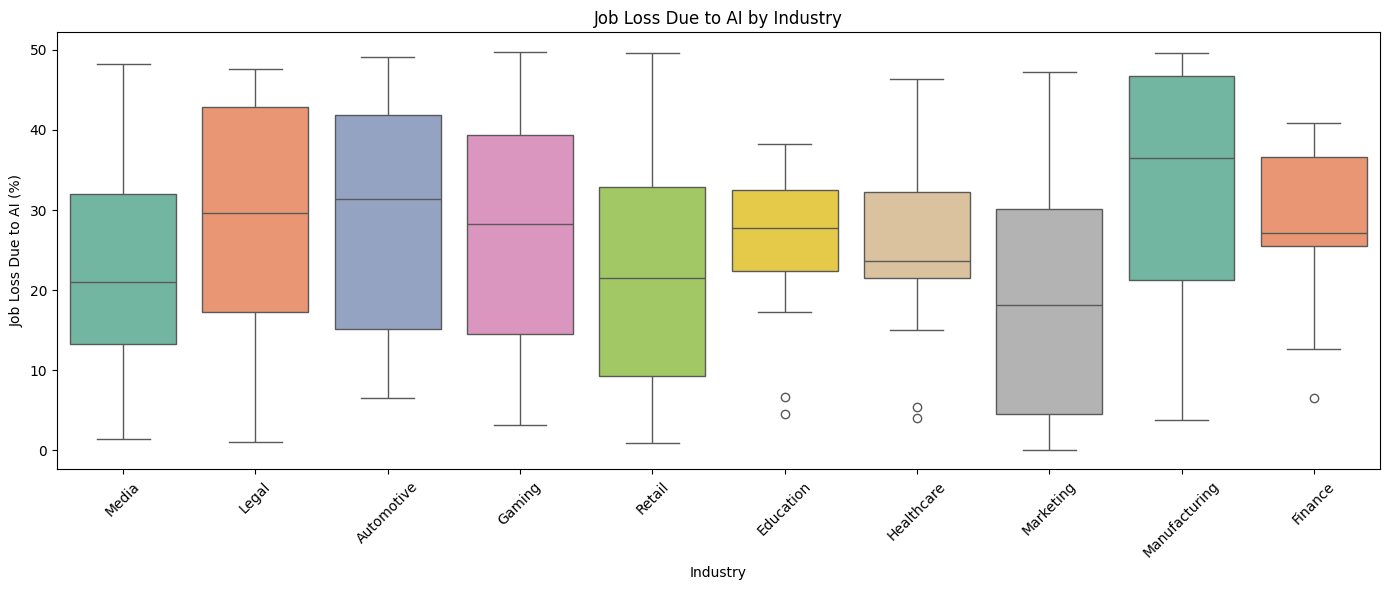

In [32]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="Industry", y="Job Loss Due to AI (%)", palette='Set2')
plt.xticks(rotation=45)
plt.title("Job Loss Due to AI by Industry")
plt.tight_layout()
plt.show()

In [33]:
#7. AI TOOL WORDCLOUD

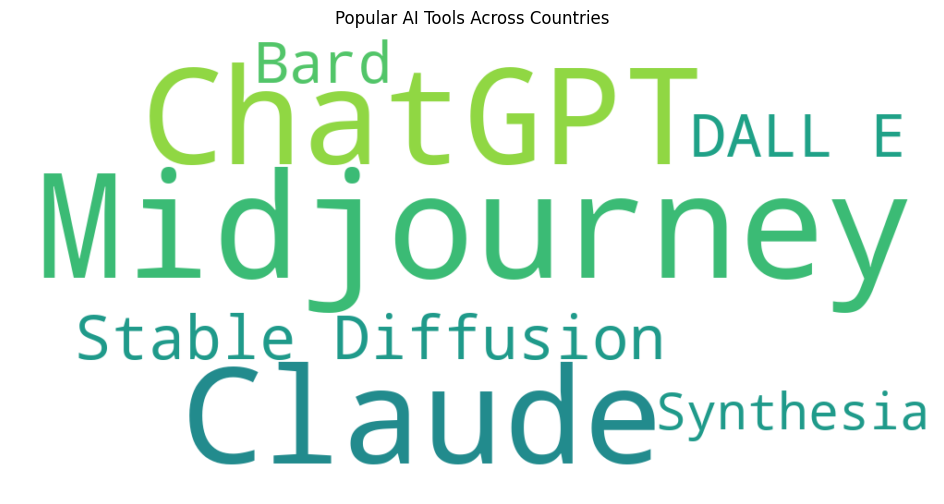

In [34]:
tools_text = ' '.join(df['Top AI Tools Used'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(tools_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular AI Tools Across Countries")
plt.show()


In [35]:
#8. FEATURE ENCODING

In [36]:
le = LabelEncoder()
df['Industry_Enc'] = le.fit_transform(df['Industry'])
df['Country_Enc'] = le.fit_transform(df['Country'])
df['Tools_Enc'] = le.fit_transform(df['Top AI Tools Used'])
df['Regulation_Enc'] = le.fit_transform(df['Regulation Status'])

In [37]:
#9. CLUSTERING (KMeans)

In [38]:
cluster_features = ['AI Adoption Rate (%)', 'Job Loss Due to AI (%)', 
                    'Revenue Increase Due to AI (%)', 'Human-AI Collaboration Rate (%)',
                    'Consumer Trust in AI (%)', 'Market Share of AI Companies (%)']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=537)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [39]:
#CLUSTER VISUALIZATION (PCA REDUCTION)

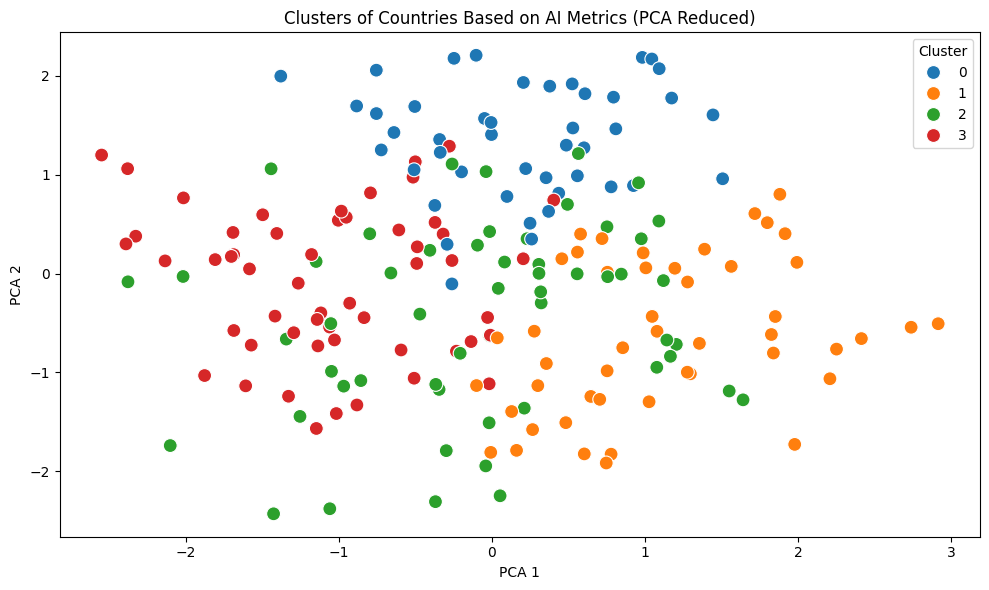

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='tab10', s=100)
plt.title("Clusters of Countries Based on AI Metrics (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [41]:
#10. RANDOM FOREST REGRESSOR (REVENUE INCREASE PREDICTION)

In [42]:
X = df[['AI Adoption Rate (%)', 'Job Loss Due to AI (%)', 
        'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)', 
        'Market Share of AI Companies (%)', 'Industry_Enc', 'Country_Enc', 'Tools_Enc', 'Regulation_Enc']]
y = df['Revenue Increase Due to AI (%)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#Random Forest

In [44]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest R2:", r2_score(y_test, rf_pred))


Random Forest R2: -0.12904270370906223


In [45]:
#Gradient Boosting

In [46]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))

Gradient Boosting R2: -0.35375347734200746


In [47]:
#Linear Regression

In [48]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: -0.11195426080327109


In [49]:
#11. PCA COMPONENT ANALYSIS

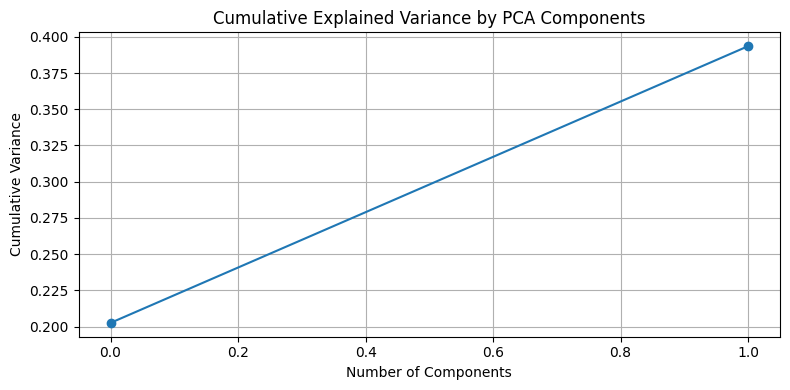

In [50]:
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, 'rf_model.pkl')

# Optional: save the scaler too, if you used it for preprocessing
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [52]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

# Load the trained model and scaler
model = joblib.load('rf_model.pkl')
scaler = joblib.load('scaler.pkl')

# Feature order used in training
FEATURES = [
    'AI Adoption Rate (%)',
    'Job Loss Due to AI (%)',
    'Revenue Increase Due to AI (%)',
    'Human-AI Collaboration Rate (%)',
    'Consumer Trust in AI (%)',
    'Market Share of AI Companies (%)'
]

@app.route('/')
def home():
    return "Welcome to the AI Impact Prediction API. Use POST /predict with JSON input."

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get JSON data from request
        data = request.get_json()

        # Extract features in the correct order
        input_data = [data.get(feature, 0) for feature in FEATURES]

        # Preprocess the input
        input_scaled = scaler.transform([input_data])

        # Make prediction
        prediction = model.predict(input_scaled)

        return jsonify({
            'input': dict(zip(FEATURES, input_data)),
            'predicted_rate_of_increase': prediction[0]
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

C:\Users\Rohith\OneDrive\Desktop\SRGECWorkshop\rohith\lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.

